<a href="https://colab.research.google.com/github/Skaims/DLAV/blob/main/DLAV_Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Trajectory Prediction with Auxiliary Depth Estimation

# 🧭 Introduction

"""
Welcome to **Phase 2** of the DLAV Projec! 🚗💨

In this phase, you'll work with a more challenging dataset that includes:
- RGB **camera images**
- Ground-truth **depth maps**
- Ground-truth **semantic segmentation** labels

Your goal is still to predict the **future trajectory** of the self-driving car (SDC), but you now have more tools at your disposal! 🎯

Here, we provide an example where **depth estimation** is used as an auxiliary task to improve trajectory prediction.

However, you're **free to explore** other auxiliary tasks (e.g., using semantic labels), different loss functions, data augmentations, or better architectures! 💡

This notebook will walk you through loading the dataset, building a model, training with and without the auxiliary task, and visualizing results.
"""

In [1]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu"
output_zip = "dlav_val.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV"
output_zip = "dlav_test_public.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=8e2d00f1-6794-465b-81ff-44e8aad46b2f
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:11<00:00, 39.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu
From (redirected): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu&confirm=t&uuid=880590e8-b19b-441e-bd61-79303ef8fa90
To: /content/dlav_val.zip
100%|██████████| 87.8M/87.8M [00:00<00:00, 138MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV
From (redirected): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV&confirm=t&uuid=cd2e13bd-c1af-4dab-b2d8-139eac5fa32e
To: /content/dlav_test_public.zip
100%|██████████| 86.6M/86.6M [00:02<00:00, 38.2MB/s]


## 📂 The Dataset

We are now working with a richer dataset that includes not just images and trajectories,
but also **depth maps** (and semantic segmentation labels, though unused in this example).

The data is stored in `.pkl` files and each file contains:
- `camera`: RGB image (shape: H x W x 3)
- `sdc_history_feature`: the past trajectory of the car
- `sdc_future_feature`: the future trajectory to predict
- `depth`: ground truth depth map (shape: H x W x 1)

We'll define a `DrivingDataset` class to load and return these tensors in a format our model can work with.

In [27]:
import os
import math
import random
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False, augment=False):
        self.samples = file_list
        self.test = test
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        camera = torch.from_numpy(data['camera']).permute(2, 0, 1).float()/255.0
        history = torch.tensor(data['sdc_history_feature'], dtype=torch.float32)
        future = None if self.test else torch.tensor(data['sdc_future_feature'], dtype=torch.float32)

        depth = torch.from_numpy(data['depth']).float()
        if depth.ndim == 3 and depth.shape[-1] == 1:
            depth = depth.squeeze(-1)
        depth = depth.unsqueeze(0)

        seg = torch.from_numpy(data['semantic_label']).long()

        # Center around the last history point
        last_pos = history[-1, :2].clone()
        history[:, :2] -= last_pos
        if future is not None:
            future[:, :2] -= last_pos

        if self.augment and not self.test:
            camera, depth, seg, history, future = self._augment(
                camera, depth, seg, history, future
            )

        out = {'camera': camera, 'history': history, 'depth': depth, 'seg': seg}
        if not self.test:
            out['future'] = future
        return out

    def _augment(self, camera, depth, seg, history, future):
        # Horizontal flip (p=0.5)
        if random.random() < 0.5:
            camera = TF.hflip(camera)
            depth = TF.hflip(depth)
            seg = TF.hflip(seg.unsqueeze(0)).squeeze(0)
            history[:, 0] = -history[:, 0]
            if future is not None:
                future[:, 0] = -future[:, 0]

        # ColorJitter on camera only (p=0.8)
        if random.random() < 0.8:
            camera = TF.adjust_brightness(camera, 1.0 + random.uniform(-0.3, 0.3))
            camera = TF.adjust_contrast(camera, 1.0 + random.uniform(-0.3, 0.3))
            camera = TF.adjust_saturation(camera, 1.0 + random.uniform(-0.2, 0.2))
            camera = camera.clamp(0.0, 1.0)

        # Rotation ±5° (p=0.4)
        if random.random() < 0.4:
            angle_deg = random.uniform(-5.0, 5.0)
            angle_rad = math.radians(angle_deg)
            cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)

            camera = TF.rotate(camera, angle_deg)
            depth = TF.rotate(depth,  angle_deg)
            seg = TF.rotate(seg.unsqueeze(0), angle_deg, interpolation=TF.InterpolationMode.NEAREST).squeeze(0)

            # Rotation 2D of coordinates x,y (in-plane)
            def rotate_xy(pts):
                x, y = pts[:, 0].clone(), pts[:, 1].clone()
                pts[:, 0] = cos_a * x + sin_a * y
                pts[:, 1] = -sin_a * x + cos_a * y
                return pts

            history = rotate_xy(history)
            if future is not None:
                future = rotate_xy(future)

        return camera, depth, seg, history, future

## 🧠 The Model: Trajectory + Depth Prediction

We've extended our trajectory prediction model to optionally include a **depth estimation decoder**.

Why?
- Predicting depth helps the model **learn richer visual features** from the camera input.
- This acts as a form of **multi-task learning**, where learning to estimate depth reinforces scene understanding, ultimately leading to better trajectory predictions.
- This can be especially useful in complex environments with occlusions or sharp turns.

The model has:
- A CNN backbone to extract features from the image
- An MLP to process historical trajectory features
- A trajectory decoder to predict future coordinates
- (Optionally) A depth decoder to predict dense depth maps

This auxiliary task is enabled by setting `use_depth_aux=True`.

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DrivingPlanner(nn.Module):
    def __init__(self, use_depth_aux=False):
        super().__init__()
        self.use_depth_aux = use_depth_aux

        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU()
        )

        self.cnn_flatten = nn.Flatten()


        # Decoder for trajectory prediction
        self.decoder = nn.Linear((32 * 100 * 150) + (21 * 3), 60 * 3)

        # Optional depth decoder
        if self.use_depth_aux:
            self.depth_decoder = nn.Sequential(
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # Upsample
                nn.ReLU(),
                nn.Conv2d(16, 1, kernel_size=3, padding=1),
                nn.Upsample(size=(200, 300), mode='bilinear', align_corners=False)
            )

    def forward(self, camera, history):
        B = camera.size(0)

        # Process camera
        cnn_feat = self.cnn_backbone(camera)         # (B, 32, 100, 150)
        feat_flat = self.cnn_flatten(cnn_feat)       # (B, 32*100*150)


        # Flatten history
        history_flat = history.view(B, -1)

        # Concatenate and decode trajectory
        combined = torch.cat([feat_flat, history_flat], dim=1)
        future = self.decoder(combined).view(B, 60, 3)

        # Optional depth map prediction
        depth_out = None
        if self.use_depth_aux:
            depth_out = self.depth_decoder(cnn_feat.detach()).permute(0, 2, 3, 1)

        return future, depth_out


In [29]:
# FPN (Feature Pyramid Network)
class LightFPN(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        self.lat4 = nn.Conv2d(512, feat_dim, 1)
        self.lat3 = nn.Conv2d(256, feat_dim, 1)
        self.lat2 = nn.Conv2d(128, feat_dim, 1)
        self.out = nn.Sequential(
            nn.Conv2d(feat_dim, feat_dim, 3, padding=1),
            nn.BatchNorm2d(feat_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, s2, s3, s4):
        p4 = self.lat4(s4)
        p4_up = F.interpolate(p4, size=s3.shape[2:], mode='nearest')
        p3 = self.lat3(s3) + p4_up
        p3_up = F.interpolate(p3, size=s2.shape[2:], mode='nearest')
        p2 = self.lat2(s2) + p3_up
        p2_dn = F.adaptive_avg_pool2d(p2, s3.shape[2:])
        return self.out(p3 + p2_dn)


class DepthEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 5, stride=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 16, out_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, depth):
        return self.net(torch.log1p(depth))


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch // 2 + skip_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class WaypointQueryDecoder(nn.Module):
    def __init__(self, future_steps=60, future_dim=3,
                 d_model=256, nhead=8, num_layers=5,
                 feat_h=12, feat_w=18, dropout=0.05):
        super().__init__()
        self.future_steps = future_steps
        self.future_dim = future_dim

        self.waypoint_queries = nn.Embedding(future_steps, d_model)
        self.register_buffer('pos_enc', self._make_pos_enc(feat_h, feat_w, d_model))

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.out_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(inplace=True),
            nn.Linear(d_model // 2, future_dim),
        )

    @staticmethod
    def _make_pos_enc(H, W, d_model):
        y_enc = torch.zeros(H, d_model // 2)
        x_enc = torch.zeros(W, d_model // 2)
        div = torch.exp(
            torch.arange(0, d_model // 2, 2).float()
            * -(math.log(10000.0) / (d_model // 2))
        )
        y_pos = torch.arange(H).float().unsqueeze(1)
        x_pos = torch.arange(W).float().unsqueeze(1)
        y_enc[:, 0::2] = torch.sin(y_pos * div)
        y_enc[:, 1::2] = torch.cos(y_pos * div)
        x_enc[:, 0::2] = torch.sin(x_pos * div)
        x_enc[:, 1::2] = torch.cos(x_pos * div)
        pos = torch.cat([
            y_enc.unsqueeze(1).expand(H, W, d_model // 2),
            x_enc.unsqueeze(0).expand(H, W, d_model // 2),
        ], dim=-1)
        return pos.view(H * W, d_model)

    def forward(self, feat_map, context):
        B, C, H, W = feat_map.shape
        mem = feat_map.flatten(2).permute(0, 2, 1)

        if H * W != self.pos_enc.shape[0]:
            pos = F.interpolate(
                self.pos_enc.T.unsqueeze(0).unsqueeze(-1),
                size=(H * W, 1), mode='bilinear', align_corners=False
            ).squeeze().T
        else:
            pos = self.pos_enc
        mem = mem + pos.unsqueeze(0)

        queries = self.waypoint_queries.weight.unsqueeze(0).expand(B, -1, -1)
        queries = queries + context.unsqueeze(1)

        out = self.transformer_decoder(queries, mem)
        return self.out_head(out)


# Main modele
class PretrainedResNetPlannerCMD(nn.Module):
    def __init__(self,
                 history_steps: int = 21,
                 future_steps: int = 60,
                 history_dim: int = 3,
                 future_dim: int = 3,
                 backbone_pretrained: bool = True,
                 history_hidden: int = 128,
                 d_model: int = 256,
                 nhead: int = 8,
                 num_decoder_layers: int = 5,
                 dropout: float = 0.05,
                 num_seg_classes: int = 15,
                 use_depth_aux: bool = True,
                 use_seg_aux: bool = True,
                 feat_h: int = 12,
                 feat_w: int = 18):
        super().__init__()

        self.future_steps = future_steps
        self.future_dim = future_dim
        self.d_model = d_model
        self.use_depth_aux = use_depth_aux
        self.use_seg_aux = use_seg_aux

        resnet = models.resnet34(
            weights=models.ResNet34_Weights.IMAGENET1K_V1 if backbone_pretrained else None
        )
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.fpn = LightFPN(feat_dim=d_model)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.img_proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(inplace=True),
        )

        self.depth_encoder = DepthEncoder(out_dim=d_model // 2)
        self.depth_feat_proj = nn.Linear(d_model // 2, d_model)

        self.history_gru = nn.GRU(
            input_size=history_dim, hidden_size=history_hidden,
            num_layers=2, batch_first=True,
            dropout=dropout, bidirectional=True,
        )
        self.hist_proj = nn.Sequential(
            nn.Linear(history_hidden * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(inplace=True),
        )

        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
        )

        self.waypoint_decoder = WaypointQueryDecoder(
            future_steps=future_steps, future_dim=future_dim,
            d_model=d_model, nhead=nhead,
            num_layers=num_decoder_layers,
            feat_h=feat_h, feat_w=feat_w,
            dropout=dropout,
        )

        self.bottleneck_proj = nn.Conv2d(512, 256, 1)
        self.up1 = UpBlock(256, 256, 128)
        self.up2 = UpBlock(128, 128, 64)
        self.up3 = UpBlock(64,  64,  32)

        if self.use_depth_aux:
            self.depth_head = nn.Sequential(
                nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
                nn.Conv2d(32, 1, 1), nn.Softplus(),
            )
        if self.use_seg_aux:
            self.seg_head = nn.Sequential(
                nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
                nn.Conv2d(64, num_seg_classes, 1),
            )

        self.register_buffer("img_mean", torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1), persistent=False)
        self.register_buffer("img_std",  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1), persistent=False)

    def encode_image(self, camera):
        x = (camera - self.img_mean) / self.img_std
        s0 = self.stem(x)
        x = self.maxpool(s0)
        s1 = self.layer1(x)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        s4 = self.layer4(s3)
        img_global = self.img_proj(self.global_pool(s4).flatten(1))
        feat_map = self.fpn(s2, s3, s4)
        return dict(s1=s1, s2=s2, s3=s3, s4=s4), img_global, feat_map

    def encode_history(self, history):
        _, h_n = self.history_gru(history)
        return self.hist_proj(torch.cat([h_n[-2], h_n[-1]], dim=1))

    def decode_spatial(self, skips):
        s4 = self.bottleneck_proj(skips['s4'])
        d = self.up1(s4,  skips['s3'])
        d = self.up2(d,   skips['s2'])
        d = self.up3(d,   skips['s1'])
        return d

    def forward(self, camera, history, depth=None,
                teacher_forcing_prob=0.0, gt_future=None):
        skips, img_feat, feat_map = self.encode_image(camera)
        hist_feat = self.encode_history(history)

        if depth is not None:
            depth_feat = self.depth_feat_proj(self.depth_encoder(depth))
        else:
            depth_feat = torch.zeros_like(img_feat)

        context = self.fusion(torch.cat([img_feat, hist_feat, depth_feat], dim=1))
        traj = self.waypoint_decoder(feat_map, context)

        depth_up = seg_up = None
        if self.use_depth_aux or self.use_seg_aux:
            d = self.decode_spatial(skips)
            d = F.interpolate(d, size=camera.shape[2:], mode='bilinear', align_corners=False)
            if self.use_depth_aux:
                depth_up = self.depth_head(d)
            if self.use_seg_aux:
                seg_up = self.seg_head(d)

        return traj, depth_up, seg_up

In [30]:
# Mixup
def mixup_batch(camera, history, future, depth, seg, alpha=0.2):
    B = camera.size(0)
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(B, device=camera.device)
    camera = lam * camera  + (1 - lam) * camera[idx]
    history = lam * history + (1 - lam) * history[idx]
    future = lam * future  + (1 - lam) * future[idx]
    depth = lam * depth   + (1 - lam) * depth[idx]

    return camera, history, future, depth, seg, lam, idx

# Loss
def temporal_traj_loss(pred, gt, T, device):
    huber = nn.SmoothL1Loss(reduction='none', beta=0.5)
    weights = torch.linspace(0.5, 1.5, T, device=device)
    per_t = huber(pred[..., :2], gt[..., :2]).sum(-1)   # (B, T)
    weighted = (per_t * weights).mean()
    way_idx = torch.tensor([9, 19, 29, 44, 59], device=device)
    wp_loss = huber(pred[:, way_idx, :2], gt[:, way_idx, :2]).mean()
    return weighted + 0.5 * wp_loss


def compute_ade_fde(pred, gt):
    err = torch.norm(pred[:, :, :2] - gt[:, :, :2], dim=2)
    return err.mean(dim=1).sum().item(), err[:, -1].sum().item(), pred.size(0)

    return weighted + 0.5 * wp_loss

In [35]:
def train(model, train_loader, val_loader,
          num_epochs=90, lr=2e-4,
          use_mixup=True, mixup_alpha=0.2, mixup_prob=0.3,
          grad_accum_steps=2,
          device=None):

    device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

    # CosineAnnealingWarmRestarts : redémarre tous les T_0 epochs
    # T_0=30 → redémarrages à ep.30, 60, 90 — aide à sortir des plateaux
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=30, T_mult=1, eta_min=lr * 0.005
    )

    # Label smoothing sur la seg pour mieux régulariser le backbone
    ce_fn  = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    T = model.future_steps

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()

        for step, batch in enumerate(tqdm(train_loader, desc=f"Train {epoch+1}/{num_epochs}")):
            cam = batch['camera'].to(device)
            hist = batch['history'].to(device)
            fut = batch['future'].to(device)
            dep = batch['depth'].to(device)
            seg = batch['seg'].to(device)   # (B, H, W) long — shape vérifiée dans Dataset

            lam = 1.0; fut2 = None; idx_mix = None
            if use_mixup and random.random() < mixup_prob:
                cam, hist, fut, dep, seg, lam, idx_mix = mixup_batch(
                    cam, hist, fut, dep, seg, alpha=mixup_alpha
                )
                fut2 = fut[idx_mix] if idx_mix is not None else None

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                fut_pred, dep_pred, seg_pred = model(cam, hist, depth=dep)

                loss = temporal_traj_loss(fut_pred, fut, T, device,
                                          lam=lam, pred2=fut_pred, gt2=fut2)

                if dep_pred is not None:
                    if dep_pred.shape[2:] != dep.shape[2:]:
                        dep_pred = F.interpolate(dep_pred, size=dep.shape[2:],
                                                 mode='bilinear', align_corners=False)
                    loss = loss + 0.1 * F.l1_loss(dep_pred, dep)

                # BUG FIX : seg shape explicitement vérifiée
                if seg_pred is not None:
                    # seg : (B, H, W), seg_pred : (B, C, H, W)
                    if seg_pred.shape[2:] != seg.shape[1:]:
                        seg_pred = F.interpolate(seg_pred, size=seg.shape[1:],
                                                 mode='bilinear', align_corners=False)
                    loss = loss + 0.1 * ce_fn(seg_pred, seg)

                loss = loss / grad_accum_steps

            scaler.scale(loss).backward()

            if (step + 1) % grad_accum_steps == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            running_loss += loss.item() * grad_accum_steps

        # CosineAnnealingWarmRestarts : step par epoch
        scheduler.step(epoch)

        # ── Validation ───────────────────────────────────────────────────
        model.eval()
        total_ade = total_fde = total_mse = 0.0
        total_seg_correct = total_seg_pixels = 0
        n = 0

        with torch.no_grad():
            for batch in val_loader:
                cam = batch['camera'].to(device)
                hist = batch['history'].to(device)
                fut = batch['future'].to(device)
                dep = batch['depth'].to(device)
                seg = batch['seg'].to(device)

                fut_pred, dep_pred, seg_pred = model(cam, hist, depth=dep)
                ade, fde, cnt = compute_ade_fde(fut_pred, fut)
                total_ade += ade; total_fde += fde
                total_mse += F.mse_loss(fut_pred, fut, reduction='sum').item()
                n += cnt

                if seg_pred is not None:
                    if seg_pred.shape[2:] != seg.shape[1:]:
                        seg_pred = F.interpolate(seg_pred, size=seg.shape[1:],
                                                 mode='bilinear', align_corners=False)
                    preds = seg_pred.argmax(dim=1)
                    total_seg_correct += (preds == seg).sum().item()
                    total_seg_pixels  += preds.numel()

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"TrainLoss {running_loss/len(train_loader):.4f} | "
            f"Val ADE {ade_avg:.4f} FDE {total_fde/n:.4f} "
            f"MSE {total_mse/(n*T*3):.4f} "
            f"SEG {total_seg_correct/max(1,total_seg_pixels):.4f} | "
            f"LR {optimizer.param_groups[0]['lr']:.2e}{tag}"
        )

In [36]:
import os
import torch.optim as optim

seed = 42
torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

NUM_SEG_CLASSES = 15
BATCH_SIZE = 32
NUM_EPOCHS = 60
LR = 3e-4

train_data_dir = "train"
val_data_dir = "val"
train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
val_files = [os.path.join(val_data_dir, f) for f in os.listdir(val_data_dir) if f.endswith('.pkl')]

train_dataset = DrivingDataset(train_files, augment=True)
val_dataset = DrivingDataset(val_files, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# Resolution of the image
sample = next(iter(train_loader))
_, _, H, W = sample['camera'].shape
feat_h, feat_w = H // 16, W // 16

model = PretrainedResNetPlannerCMD(
    history_steps=21,
    future_steps=60,
    d_model=256,
    nhead=8,
    num_decoder_layers=5,
    dropout=0.05,
    num_seg_classes=15,
    use_depth_aux=True,
    use_seg_aux=True,
    feat_h=feat_h,
    feat_w=feat_w,
)

train(model, train_loader, val_loader, num_epochs=90, lr=2e-4, use_mixup=True, mixup_alpha=0.2, mixup_prob=0.3, grad_accum_steps=2)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Train 1/90: 100%|██████████| 157/157 [00:4

Epoch 1/90 | TrainLoss 34.1410 | Val ADE 4.1775 FDE 8.0377 MSE 15.6028 SEG 0.9000 | LR 2.00e-04


Train 2/90: 100%|██████████| 157/157 [00:46<00:00,  3.41it/s]


Epoch 2/90 | TrainLoss 27.9791 | Val ADE 3.6208 FDE 8.6033 MSE 11.7481 SEG 0.8704 | LR 1.99e-04


Train 3/90: 100%|██████████| 157/157 [00:46<00:00,  3.40it/s]


...

Epoch 88/90 | TrainLoss 0.8284 | Val ADE 1.6365 FDE 4.4224 MSE 4.0979 SEG 0.9582 | LR 5.87e-06


Train 89/90: 100%|██████████| 157/157 [00:45<00:00,  3.46it/s]


Epoch 89/90 | TrainLoss 0.8180 | Val ADE 1.6418 FDE 4.4363 MSE 4.1297 SEG 0.9582 | LR 3.17e-06


Train 90/90: 100%|██████████| 157/157 [00:46<00:00,  3.40it/s]


Epoch 90/90 | TrainLoss 0.8109 | Val ADE 1.6422 FDE 4.4454 MSE 4.1045 SEG 0.9580 | LR 1.55e-06


## 🔍 Final Visualization and Comparison

Now that we’ve trained two models — one **with** the depth auxiliary task and one **without** — let’s visualize and compare their predictions.

We’ll show:
1. The **camera image** from selected validation examples
2. The **past trajectory**, **ground-truth future**, and **predicted future** trajectory
3. The **predicted vs. ground-truth depth maps** (only for the model trained with the auxiliary task)

These visualizations help us understand:
- Does the predicted trajectory better match the future when the depth task is included?
- Is the predicted depth map reasonably accurate?

Let’s see the difference! 📈

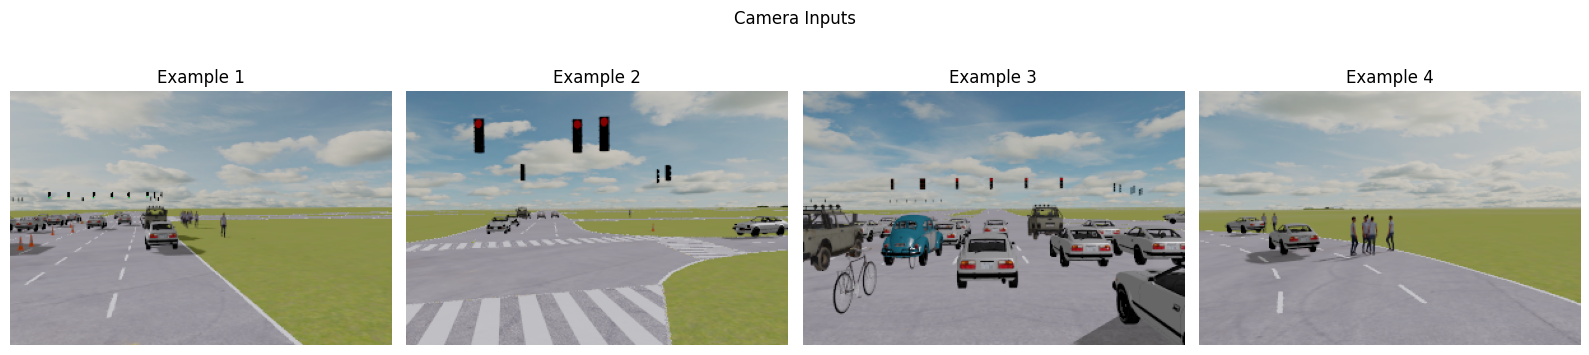

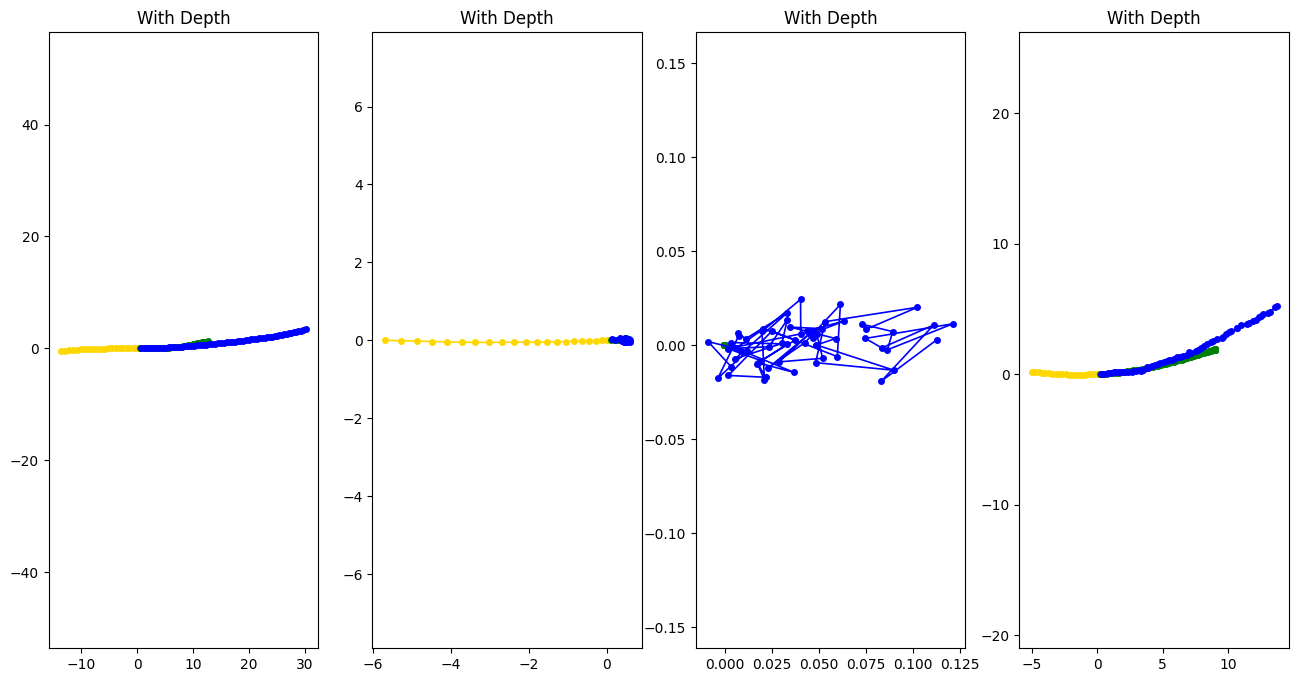

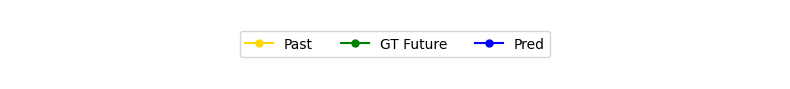

<Figure size 640x480 with 0 Axes>

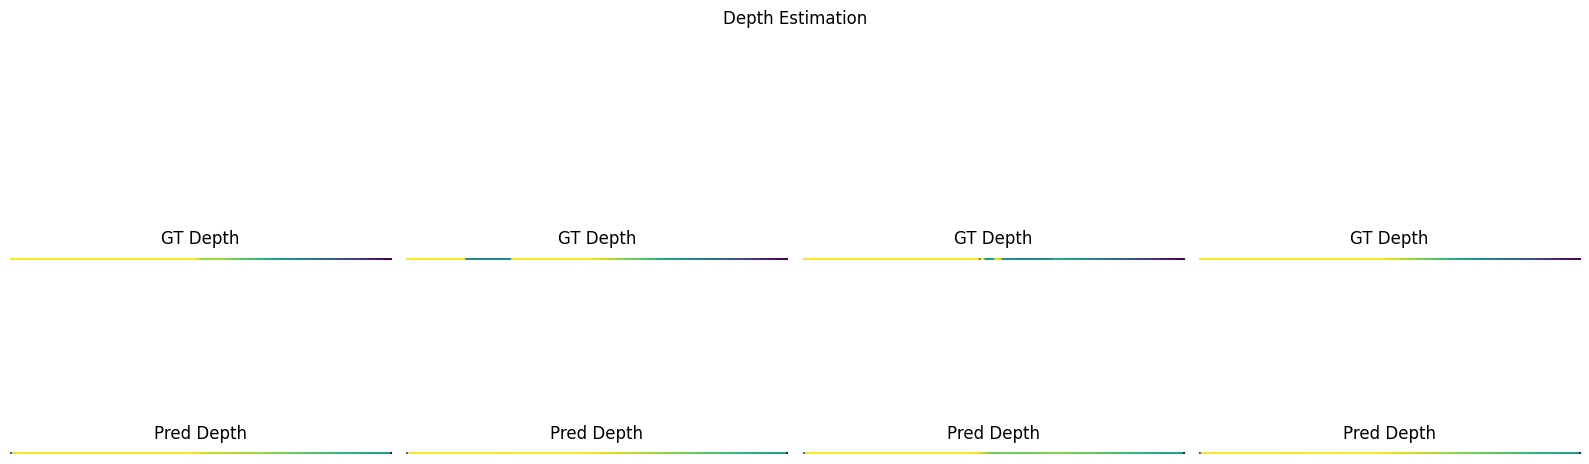

In [22]:
import matplotlib.pyplot as plt
import random

random.seed(40)

def visualize_comparison(val_loader, model, device):
    model.eval()
    val_batch = next(iter(val_loader))

    camera = val_batch['camera'].to(device)
    history = val_batch['history'].to(device)
    future = val_batch['future'].to(device)
    dep = val_batch['depth'].to(device)

    with torch.no_grad():
        pred, pred_depth, _ = model(camera, history, depth=dep)

    camera = camera.cpu().numpy()
    history = history.cpu().numpy()
    future = future.cpu().numpy()
    pred= pred.cpu().numpy()
    dep = dep.cpu().numpy()
    pred_depth = pred_depth.cpu().numpy() if pred_depth is not None else None

    k = 4
    indices = random.choices(np.arange(len(camera)), k=k)

    # Show the input camera images
    fig, ax = plt.subplots(1, k, figsize=(4 * k, 4))
    for i, idx in enumerate(indices):
        ax[i].imshow(camera[idx].transpose(1, 2, 0))
        ax[i].set_title(f"Example {i+1}")
        ax[i].axis("off")
    plt.suptitle("Camera Inputs")
    plt.tight_layout()
    plt.show()

    # Compare predicted trajectories
    fig, ax = plt.subplots(1, k, figsize=(4 * k, 8))
    for i, idx in enumerate(indices):
        # With depth
        ax[i].plot(history[idx, :, 0], history[idx, :, 1], 'o-', label='Past', color='gold', markersize=4, linewidth=1.2)
        ax[i].plot(future[idx, :, 0], future[idx, :, 1], 'o-', label='GT Future', color='green', markersize=4, linewidth=1.2)
        ax[i].plot(pred[idx, :, 0], pred[idx, :, 1], 'o-', label='Pred', color='blue', markersize=4, linewidth=1.2)
        ax[i].set_title("With Depth")
        ax[i].axis("equal")

    # Show full legend in a new figure
    fig_legend = plt.figure(figsize=(8, 1))
    legend_handles = [
        plt.Line2D([0], [0], color='gold', marker='o', linestyle='-', markersize=5, label='Past'),
        plt.Line2D([0], [0], color='green', marker='o', linestyle='-', markersize=5, label='GT Future'),
        plt.Line2D([0], [0], color='blue', marker='o', linestyle='-', markersize=5, label='Pred')
    ]
    fig_legend.legend(handles=legend_handles, loc='center', ncol=4)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    plt.suptitle("Trajectory Prediction: Without vs With Depth Aux Task")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Show predicted vs GT depth (only for bottom row)
    if pred_depth is not None:
        fig, ax = plt.subplots(2, k, figsize=(4 * k, 6))
        for i, idx in enumerate(indices):
            ax[0, i].imshow(dep[idx, :, :, 0], cmap='viridis')
            ax[0, i].set_title("GT Depth", pad=10)
            ax[0, i].axis("off")
            # increase vertical distance between rows

            ax[1, i].imshow(pred_depth[idx, :, :, 0], cmap='viridis')
            ax[1, i].set_title("Pred Depth", pad=10)
            ax[1, i].axis("off")

        plt.suptitle("Depth Estimation", y=1.05)
        plt.subplots_adjust(hspace=0.4)
        plt.tight_layout()
        plt.show()


# 🔚 Call at the end after training both models
visualize_comparison(val_loader, model, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

Now we run our model on the test set once, to get the plan of our model and save it for submission. Notice that the ground truth plans are removed for the test set, so you can not calculate the ADE metric on the test set yourself, and need to submit it to the leader board. By running the last cell, you'll be able to see a csv file called submission_phase2.csv by clicking on the folder icon on the left. Download it and submit it to the leaderboard to get your score.

In [23]:
with open(f"test_public/0.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Note the absence of sdc_future_feature

dict_keys(['camera', 'depth', 'driving_command', 'sdc_history_feature', 'semantic_label'])


In [25]:
import pandas as pd
test_data_dir = "test_public"
test_files = [os.path.join(test_data_dir, fn) for fn in sorted([f for f in os.listdir(test_data_dir) if f.endswith(".pkl")], key=lambda fn: int(os.path.splitext(fn)[0]))]
test_dataset = DrivingDataset(test_files, test=True)
test_loader = DataLoader(test_dataset, batch_size=250, num_workers=2)
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
model.eval()
all_plans = []
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)
        dep = batch['depth'].to(device)

        pred_future, _, _ = model(camera, history, depth=dep)
        all_plans.append(pred_future.cpu().numpy()[..., :2])
all_plans = np.concatenate(all_plans, axis=0)

# Now save the plans as a csv file
pred_xy = all_plans[..., :2]  # shape: (total_samples, T, 2)

# Flatten to (total_samples, T*2)
total_samples, T, D = pred_xy.shape
pred_xy_flat = pred_xy.reshape(total_samples, T * D)

# Build a DataFrame with an ID column
ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

# Save to CSV
df_xy.to_csv("submission3_phase2.csv", index=False)

print(f"Shape of df_xy: {df_xy.shape}")

Shape of df_xy: (1000, 121)
